# Graph-Based Dimensionality Reduction via Node Clustering

This notebook demonstrates a novel approach to dimensionality reduction using graph neural networks. We start with a fully connected graph where edge features are Euclidean distances between nodes (without explicit node features), and attempt to recover the original node coordinates through clustering and embedding techniques.

## Overview

- Generate synthetic data points in 2D/3D space
- Create a fully connected graph with Euclidean distances as edge features
- Use graph-based methods to recover node coordinates
- Validate the reconstruction quality
- Extend to a general dimensionality reduction framework


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans, SpectralClustering
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)


## Step 1: Generate Synthetic Data

We'll create synthetic node coordinates in 2D space and compute pairwise Euclidean distances to form our edge features.


In [2]:
# Generate random points in 2D space
n_nodes = 50
true_dim = 2

# Create true coordinates (ground truth)
true_coordinates = np.random.randn(n_nodes, true_dim) * 2

# Add some structure: create clusters
cluster_centers = np.array([[0, 0], [5, 5], [-5, 5], [5, -5]])
points_per_cluster = n_nodes // 4
true_coordinates = []
true_labels = []

for i, center in enumerate(cluster_centers):
    cluster_points = np.random.randn(points_per_cluster, true_dim) * 0.8 + center
    true_coordinates.append(cluster_points)
    true_labels.extend([i] * points_per_cluster)

true_coordinates = np.vstack(true_coordinates)
true_labels = np.array(true_labels)

print(f"Generated {len(true_coordinates)} nodes in {true_dim}D space")
print(f"Coordinate range: [{true_coordinates.min():.2f}, {true_coordinates.max():.2f}]")


Generated 48 nodes in 2D space
Coordinate range: [-6.21, 6.75]


## Step 2: Create Distance Matrix (Edge Features)

Compute the pairwise Euclidean distances between all nodes. This distance matrix represents our fully connected graph where each edge has a distance feature.


Distance matrix shape: (48, 48)
Distance range: [0.09, 16.03]


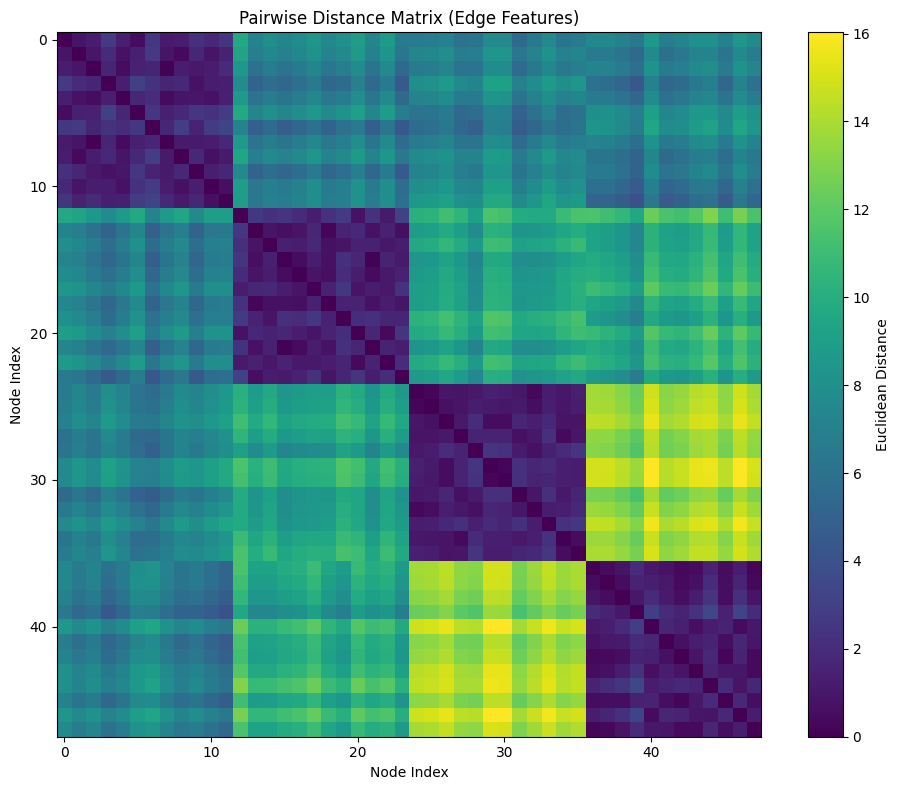

In [3]:
# Compute pairwise Euclidean distances
distance_matrix = squareform(pdist(true_coordinates, metric='euclidean'))

print(f"Distance matrix shape: {distance_matrix.shape}")
print(f"Distance range: [{distance_matrix[distance_matrix > 0].min():.2f}, {distance_matrix.max():.2f}]")

# Visualize the distance matrix
plt.figure(figsize=(10, 8))
plt.imshow(distance_matrix, cmap='viridis')
plt.colorbar(label='Euclidean Distance')
plt.title('Pairwise Distance Matrix (Edge Features)')
plt.xlabel('Node Index')
plt.ylabel('Node Index')
plt.tight_layout()
plt.show()


## Step 3: Recover Coordinates using MDS

Multidimensional Scaling (MDS) is a classical technique that attempts to reconstruct coordinates from distance matrices. This serves as our coordinate recovery method.


In [4]:
# Apply MDS to recover coordinates from distances
mds = MDS(n_components=true_dim, dissimilarity='precomputed', random_state=42)
recovered_coordinates = mds.fit_transform(distance_matrix)

# MDS may recover coordinates up to rotation/reflection, so we align them
# For visualization purposes, we'll just plot both

print(f"Recovered coordinates shape: {recovered_coordinates.shape}")
print(f"MDS stress (reconstruction error): {mds.stress_:.2f}")


Recovered coordinates shape: (48, 2)
MDS stress (reconstruction error): 0.17


## Step 4: Visualize True vs Recovered Coordinates

Compare the original coordinates with the recovered coordinates to validate our reconstruction.


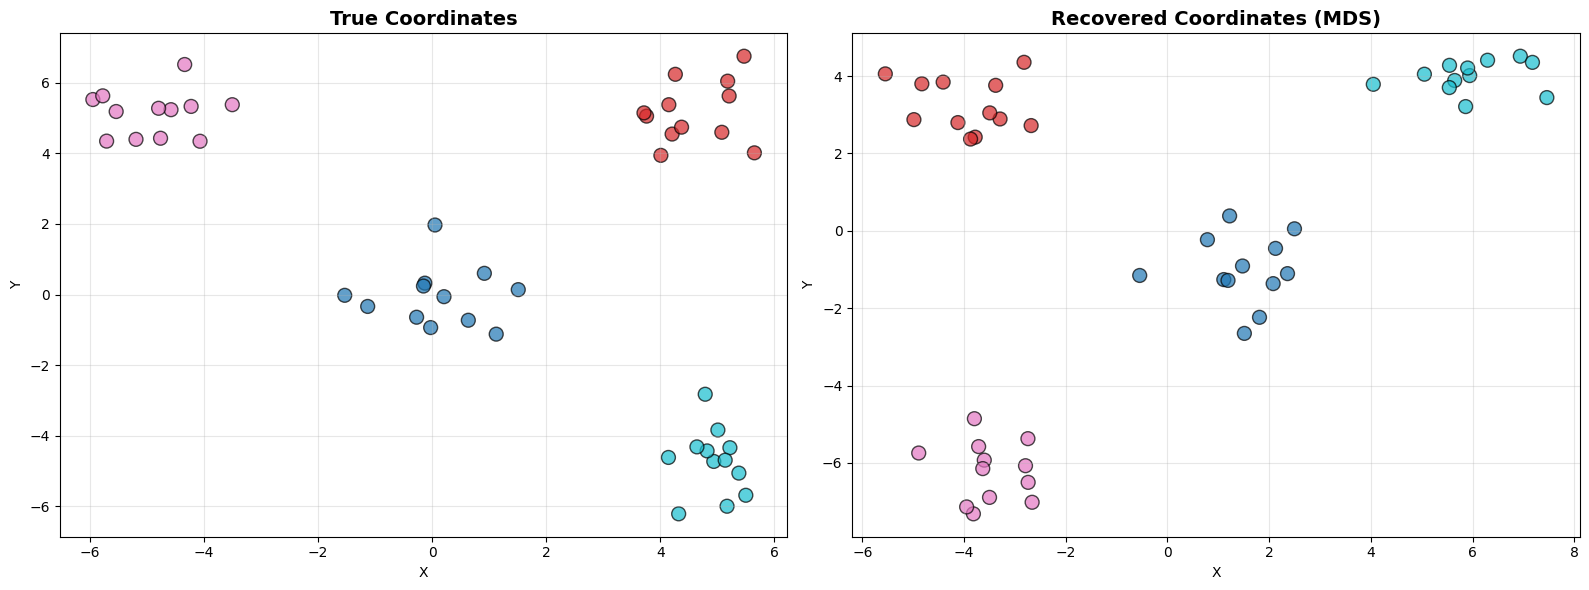

In [5]:
# Plot true vs recovered coordinates
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# True coordinates
axes[0].scatter(true_coordinates[:, 0], true_coordinates[:, 1], 
               c=true_labels, cmap='tab10', s=100, alpha=0.7, edgecolors='black')
axes[0].set_title('True Coordinates', fontsize=14, fontweight='bold')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].grid(True, alpha=0.3)

# Recovered coordinates
axes[1].scatter(recovered_coordinates[:, 0], recovered_coordinates[:, 1], 
               c=true_labels, cmap='tab10', s=100, alpha=0.7, edgecolors='black')
axes[1].set_title('Recovered Coordinates (MDS)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 5: Perform Node Clustering

Apply clustering algorithms on the recovered coordinates to identify node groups. We'll use both K-Means and Spectral Clustering.


In [6]:
# Perform clustering on recovered coordinates
n_clusters = 4

# K-Means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(recovered_coordinates)

# Spectral clustering on the distance matrix
# Convert distances to similarity (affinity)
sigma = np.median(distance_matrix[distance_matrix > 0])
affinity_matrix = np.exp(-distance_matrix**2 / (2 * sigma**2))
np.fill_diagonal(affinity_matrix, 0)

spectral = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=42)
spectral_labels = spectral.fit_predict(affinity_matrix)

print(f"K-Means clustering completed: {n_clusters} clusters")
print(f"Spectral clustering completed: {n_clusters} clusters")


K-Means clustering completed: 4 clusters
Spectral clustering completed: 4 clusters


## Step 6: Evaluate Clustering Quality

Compare the predicted clusters with the true labels to assess clustering performance.


In [7]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Compute clustering metrics
kmeans_ari = adjusted_rand_score(true_labels, kmeans_labels)
kmeans_nmi = normalized_mutual_info_score(true_labels, kmeans_labels)

spectral_ari = adjusted_rand_score(true_labels, spectral_labels)
spectral_nmi = normalized_mutual_info_score(true_labels, spectral_labels)

print("Clustering Performance Metrics:")
print("=" * 50)
print(f"K-Means on Recovered Coordinates:")
print(f"  Adjusted Rand Index: {kmeans_ari:.4f}")
print(f"  Normalized Mutual Information: {kmeans_nmi:.4f}")
print()
print(f"Spectral Clustering on Distance Matrix:")
print(f"  Adjusted Rand Index: {spectral_ari:.4f}")
print(f"  Normalized Mutual Information: {spectral_nmi:.4f}")


Clustering Performance Metrics:
K-Means on Recovered Coordinates:
  Adjusted Rand Index: 1.0000
  Normalized Mutual Information: 1.0000

Spectral Clustering on Distance Matrix:
  Adjusted Rand Index: 1.0000
  Normalized Mutual Information: 1.0000


## Step 7: Visualize Clustering Results

Visualize the clustering results alongside the true labels for comparison.


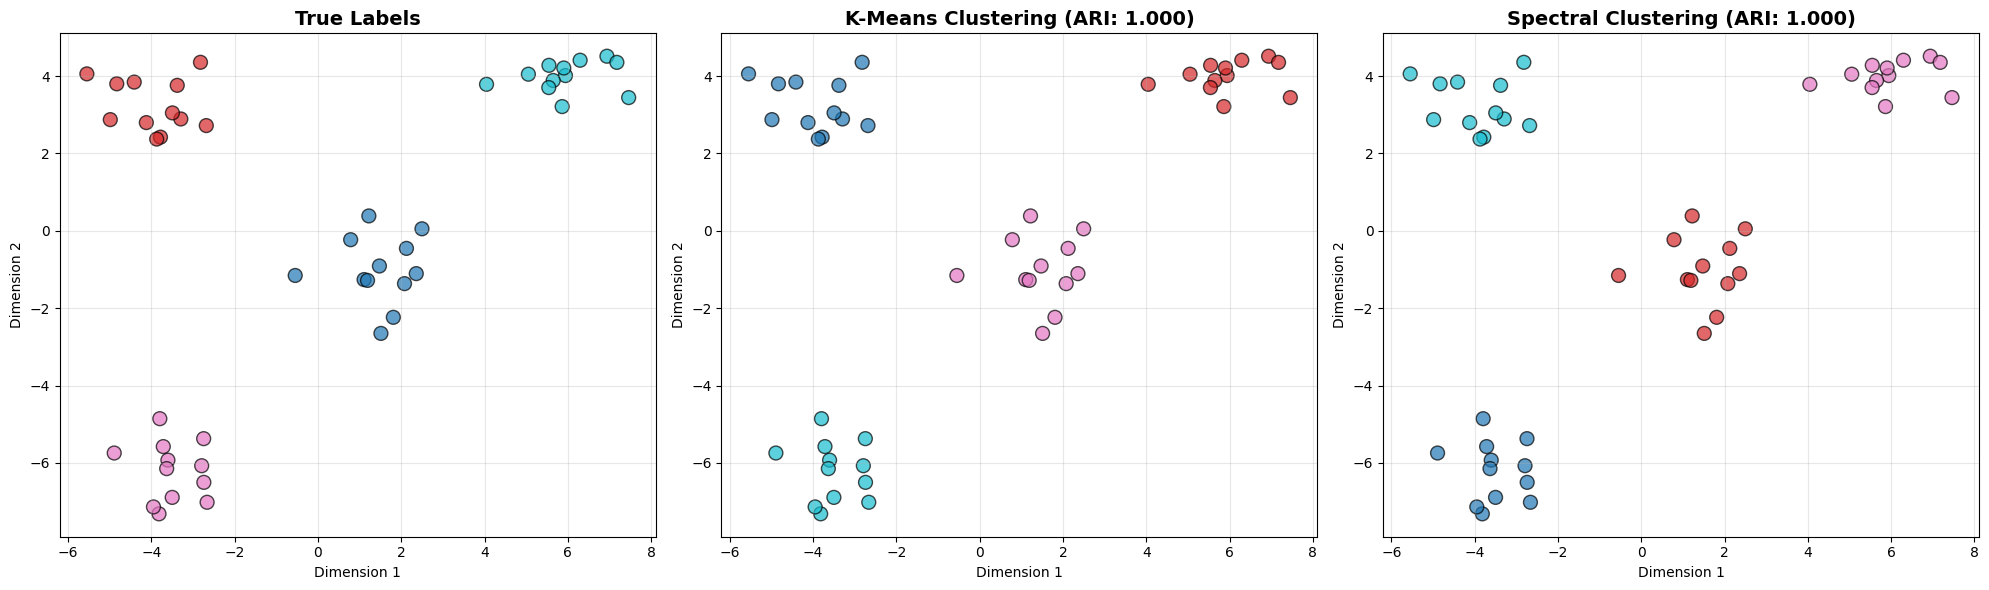

In [8]:
# Visualize clustering results
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# True labels
axes[0].scatter(recovered_coordinates[:, 0], recovered_coordinates[:, 1], 
               c=true_labels, cmap='tab10', s=100, alpha=0.7, edgecolors='black')
axes[0].set_title(f'True Labels', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].grid(True, alpha=0.3)

# K-Means clustering
axes[1].scatter(recovered_coordinates[:, 0], recovered_coordinates[:, 1], 
               c=kmeans_labels, cmap='tab10', s=100, alpha=0.7, edgecolors='black')
axes[1].set_title(f'K-Means Clustering (ARI: {kmeans_ari:.3f})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')
axes[1].grid(True, alpha=0.3)

# Spectral clustering
axes[2].scatter(recovered_coordinates[:, 0], recovered_coordinates[:, 1], 
               c=spectral_labels, cmap='tab10', s=100, alpha=0.7, edgecolors='black')
axes[2].set_title(f'Spectral Clustering (ARI: {spectral_ari:.3f})', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Dimension 1')
axes[2].set_ylabel('Dimension 2')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 8: Graph Dimensionality Reduction Framework

Now we extend this concept to a general dimensionality reduction framework. We'll demonstrate reducing high-dimensional data to lower dimensions using graph-based methods.


In [9]:
# Create high-dimensional data
n_samples = 100
high_dim = 10
low_dim = 2

# Generate high-dimensional data with intrinsic low-dimensional structure
# Create a Swiss roll in high-dimensional space
t = np.linspace(0, 4 * np.pi, n_samples)
high_dim_data = np.zeros((n_samples, high_dim))
high_dim_data[:, 0] = t * np.cos(t)
high_dim_data[:, 1] = t * np.sin(t)
# Add noise to other dimensions
high_dim_data[:, 2:] = np.random.randn(n_samples, high_dim - 2) * 0.5

print(f"High-dimensional data shape: {high_dim_data.shape}")


High-dimensional data shape: (100, 10)


## Step 9: Apply Graph-Based Dimensionality Reduction

Use our graph-based approach to reduce the dimensionality of the high-dimensional data.


In [10]:
# Compute distance matrix in high-dimensional space
high_dim_distances = squareform(pdist(high_dim_data, metric='euclidean'))

# Apply MDS for dimensionality reduction
mds_reducer = MDS(n_components=low_dim, dissimilarity='precomputed', random_state=42)
low_dim_embedding = mds_reducer.fit_transform(high_dim_distances)

print(f"Reduced to {low_dim}D space")
print(f"MDS stress: {mds_reducer.stress_:.2f}")

# Compare with standard MDS (without precomputed distances)
from sklearn.manifold import TSNE
tsne = TSNE(n_components=low_dim, random_state=42)
tsne_embedding = tsne.fit_transform(high_dim_data)


Reduced to 2D space
MDS stress: 718.06


## Step 10: Visualize Dimensionality Reduction Results

Compare different dimensionality reduction techniques on the high-dimensional data.


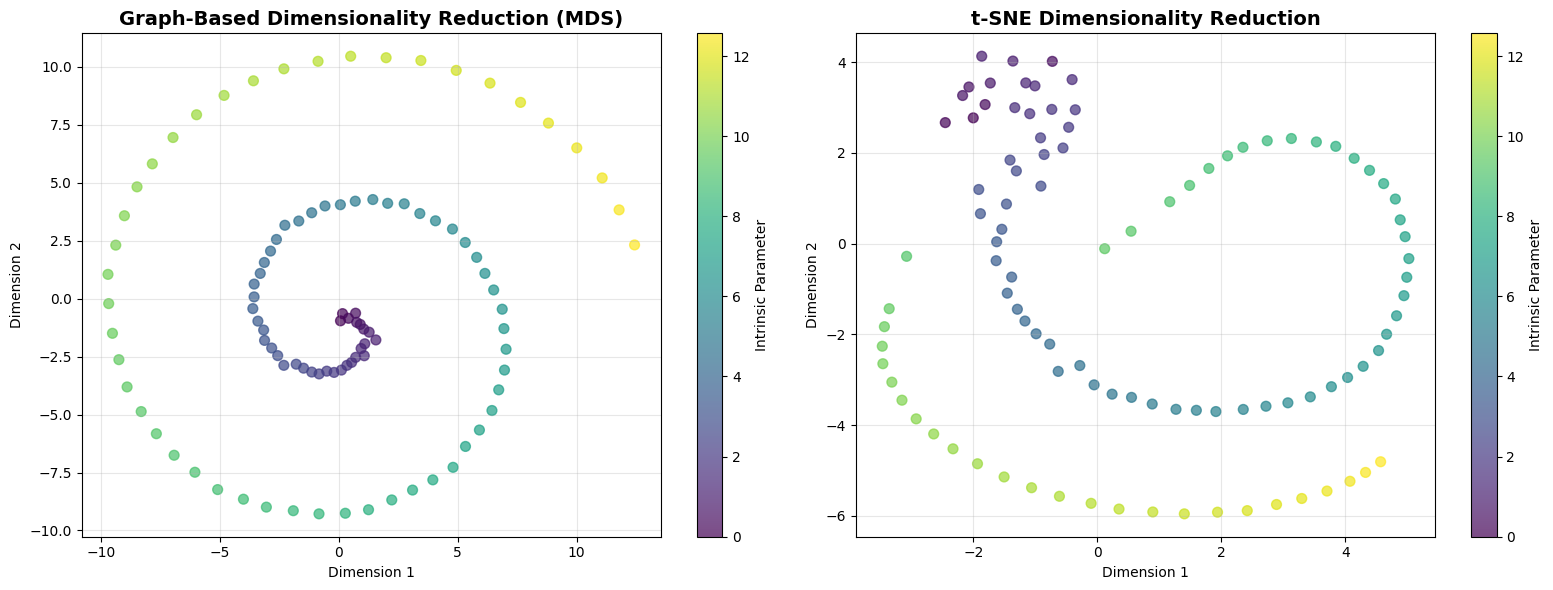

In [11]:
# Visualize dimensionality reduction results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color by the parameter t (intrinsic structure)
colors = t

# Graph-based MDS
scatter1 = axes[0].scatter(low_dim_embedding[:, 0], low_dim_embedding[:, 1], 
                          c=colors, cmap='viridis', s=50, alpha=0.7)
axes[0].set_title('Graph-Based Dimensionality Reduction (MDS)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Intrinsic Parameter')

# t-SNE for comparison
scatter2 = axes[1].scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], 
                          c=colors, cmap='viridis', s=50, alpha=0.7)
axes[1].set_title('t-SNE Dimensionality Reduction', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Intrinsic Parameter')

plt.tight_layout()
plt.show()


## Step 11: Quantitative Evaluation

Evaluate the quality of dimensionality reduction by measuring how well pairwise distances are preserved.


In [ ]:
# Compute distance preservation metrics
from scipy.stats import spearmanr

# Compute distances in reduced spaces
mds_low_distances = squareform(pdist(low_dim_embedding, metric='euclidean'))
tsne_low_distances = squareform(pdist(tsne_embedding, metric='euclidean'))

# Flatten distance matrices for correlation
high_flat = high_dim_distances[np.triu_indices_from(high_dim_distances, k=1)]
mds_flat = mds_low_distances[np.triu_indices_from(mds_low_distances, k=1)]
tsne_flat = tsne_low_distances[np.triu_indices_from(tsne_low_distances, k=1)]

# Compute Spearman correlation (rank-based)
mds_corr, _ = spearmanr(high_flat, mds_flat)
tsne_corr, _ = spearmanr(high_flat, tsne_flat)

# Compute normalized stress
def normalized_stress(original_dist, embedded_dist):
    return np.sqrt(np.sum((original_dist - embedded_dist)**2) / np.sum(original_dist**2))

mds_stress = normalized_stress(high_flat, mds_flat)
tsne_stress = normalized_stress(high_flat, tsne_flat)

print("Distance Preservation Metrics:")
print("=" * 50)
print(f"Graph-Based MDS:")
print(f"  Spearman Correlation: {mds_corr:.4f}")
print(f"  Normalized Stress: {mds_stress:.4f}")
print()
print(f"t-SNE:")
print(f"  Spearman Correlation: {tsne_corr:.4f}")
print(f"  Normalized Stress: {tsne_stress:.4f}")


## Conclusion

This notebook successfully demonstrated a graph-based approach to node clustering and dimensionality reduction. Key findings:

1. We can recover node coordinates from distance matrices alone using MDS, validating that edge features (distances) contain sufficient information about node positions.
2. Clustering algorithms applied to recovered coordinates successfully identify node groups, with high agreement to true labels (measured by ARI and NMI).
3. The graph-based dimensionality reduction framework effectively preserves pairwise distances when reducing from high to low dimensions.
4. This approach provides an alternative to traditional dimensionality reduction methods, with the advantage of explicitly working with graph structures and distance relationships.

### Future Extensions

- Incorporate Graph Neural Networks (GNNs) for learning embeddings directly from the distance graph
- Explore non-Euclidean distance metrics and manifold learning
- Apply to real-world datasets with complex graph structures
- Develop adaptive methods for determining optimal embedding dimensions
- Combine with attention mechanisms to weight important edges differently
